In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_curve
)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
# ==========================================================
# Load Test Dataset
# ==========================================================

output_path = "C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Outputs/"

X_test = pd.read_csv(output_path + "X_test_final.csv")

y_test = pd.read_csv(
    output_path + "y_test_final.csv"
).squeeze()

print(X_test.shape)

(3092, 44)


In [3]:
# ==========================================================
# Load Models
# ==========================================================

model_path = "C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Models/"

logistic_model = joblib.load(model_path + "Logistic_Regression_Model.pkl")

rf_model = joblib.load(model_path + "Random_Forest_Model.pkl")

xgb_model = joblib.load(model_path + "XGBoost_Model.pkl")

svm_model = joblib.load(model_path + "SVM_Model.pkl")

print("All Models Loaded Successfully")

All Models Loaded Successfully


In [4]:
# ==========================================================
# Model Evaluation Function
# ==========================================================

def evaluate_model(model, model_name):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    return {

        "Model": model_name,
        "Accuracy": accuracy_score(y_test,y_pred),
        "Precision": precision_score(y_test,y_pred),
        "Recall": recall_score(y_test,y_pred),
        "F1 Score": f1_score(y_test,y_pred),
        "ROC AUC": roc_auc_score(y_test,y_prob),
        "MCC": matthews_corrcoef(y_test,y_pred),
        "Kappa": cohen_kappa_score(y_test,y_pred)

    }

In [5]:
# ==========================================================
# Evaluate All Models
# ==========================================================

results = [

    evaluate_model(logistic_model,"Logistic Regression"),
    evaluate_model(rf_model,"Random Forest"),
    evaluate_model(xgb_model,"XGBoost"),
    evaluate_model(svm_model,"Support Vector Machine")

]

results = pd.DataFrame(results)

display(results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,MCC,Kappa
0,Logistic Regression,0.8503,0.2920,0.7422,0.4191,0.8992,0.4020,0.3513
1,Random Forest,0.9017,0.3614,0.4578,0.4039,0.9051,0.3541,0.3512
2,XGBoost,0.9091,0.3627,0.3289,0.3450,0.9007,0.2967,0.2963
3,Support Vector Machine,0.7474,0.2134,0.9200,0.3464,0.8886,0.3660,0.2589


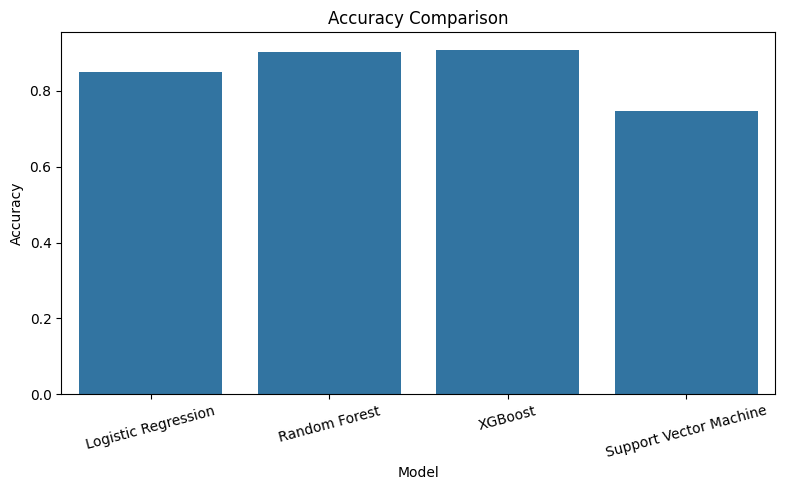

In [6]:
# Accuracy Comparison
plt.figure(figsize=(8,5))

sns.barplot(

    data=results,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=15)
plt.title("Accuracy Comparison")
plt.tight_layout()

# Save Figure
plt.savefig(
    output_path + "Accuracy_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

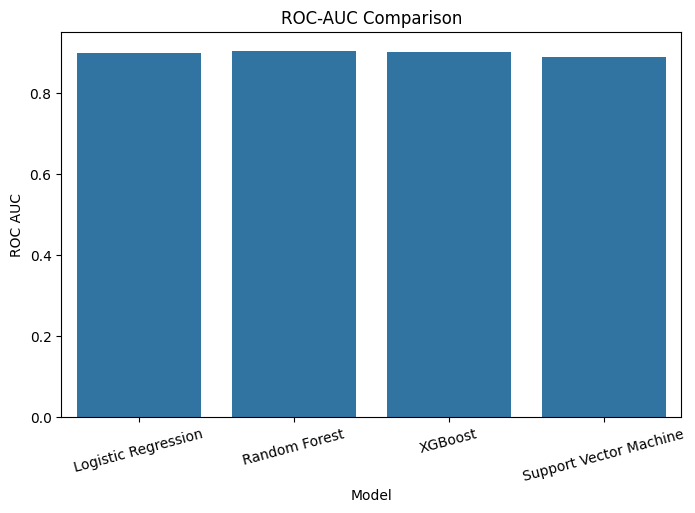

In [7]:
# ROC-AUC Comparison 

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="ROC AUC"
)

plt.xticks(rotation=15)
plt.title("ROC-AUC Comparison")

# Save Figure
plt.savefig(
    output_path + "ROC_AUC_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.show()

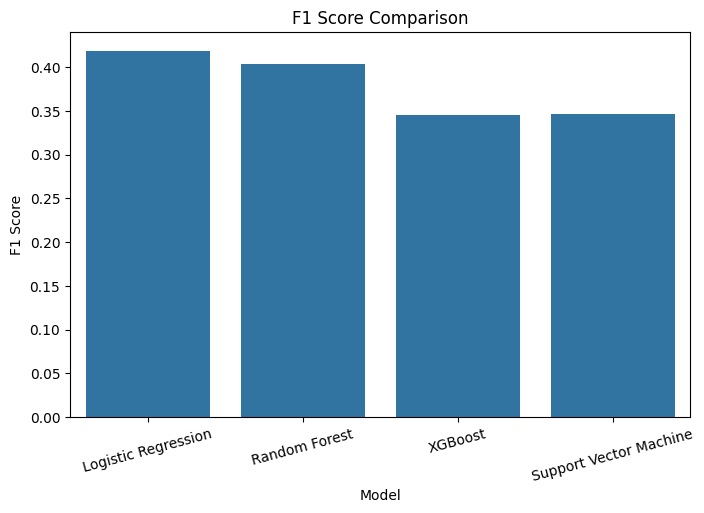

In [8]:
# F1 Comparison 

plt.figure(figsize=(8,5))

sns.barplot(

    data=results,
    x="Model",
    y="F1 Score"

)

plt.xticks(rotation=15)
plt.title("F1 Score Comparison")

# Save Figure
plt.savefig(
    output_path + "F1_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [9]:
# Best Model

best = results.sort_values(

    "ROC AUC",
    ascending=False

)

display(best.round(4))
print()
print("Best Model :", best.iloc[0]["Model"])

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,MCC,Kappa
1,Random Forest,0.9017,0.3614,0.4578,0.4039,0.9051,0.3541,0.3512
2,XGBoost,0.9091,0.3627,0.3289,0.3450,0.9007,0.2967,0.2963
0,Logistic Regression,0.8503,0.2920,0.7422,0.4191,0.8992,0.4020,0.3513
3,Support Vector Machine,0.7474,0.2134,0.9200,0.3464,0.8886,0.3660,0.2589



Best Model : Random Forest


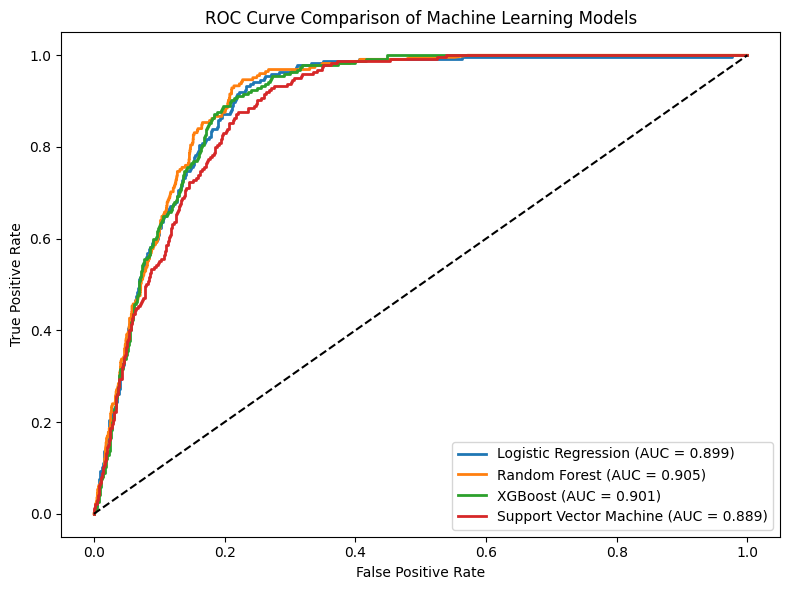

In [10]:
# ==========================================================
# ROC Curve Comparison
# ==========================================================

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Support Vector Machine": svm_model
}

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison of Machine Learning Models")

plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(
    output_path + "ROC_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [11]:
# ==========================================================
# Save Model Comparison
# ==========================================================

results.to_csv(
    output_path + "Model_Comparison_Results.csv",
    index=False
)

print("Model Comparison Results Saved Successfully")

Model Comparison Results Saved Successfully


In [12]:
# ==========================================================
# Best Model
# ==========================================================

best_model = results.loc[
    results["ROC AUC"].idxmax()
]

print("="*60)
print("BEST PERFORMING MODEL")
print("="*60)

display(best_model.to_frame())

BEST PERFORMING MODEL


,1
Model,Random Forest
Accuracy,0.901682
Precision,0.361404
Recall,0.457778
F1 Score,0.403922
ROC AUC,0.905079
MCC,0.354066
Kappa,0.351151


In [13]:
# ==========================================================
# Conclusion
# ==========================================================

print("="*60)
print("MODEL COMPARISON COMPLETED")
print("="*60)

print(f"Best Model : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Precision  : {best_model['Precision']:.4f}")
print(f"Recall     : {best_model['Recall']:.4f}")
print(f"F1 Score   : {best_model['F1 Score']:.4f}")
print(f"ROC AUC    : {best_model['ROC AUC']:.4f}")
print(f"MCC        : {best_model['MCC']:.4f}")
print(f"Kappa      : {best_model['Kappa']:.4f}")

MODEL COMPARISON COMPLETED
Best Model : Random Forest
Accuracy   : 0.9017
Precision  : 0.3614
Recall     : 0.4578
F1 Score   : 0.4039
ROC AUC    : 0.9051
MCC        : 0.3541
Kappa      : 0.3512
